# Key Estimation Demo

Run the following cells to import packages for this demo. We use many functions from `utils.py`, such as for running the baseline methods and analysis.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import utils as u
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from collections import Counter
import IPython.display as ipd

/Users/jeffreygordon/Dev/School/MIR/mir-key-estimation/.venv/lib/python3.13/site-packages/madmom/processors.py:63: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  obj = pickle.load(f, encoding='latin1')


# Setup

### Load Data

We used the FMAK (FreeMusicArchive Keys) dataset for our project, which can be found here: https://zenodo.org/records/10719860. This includes 5,489 songs along with their "expert-level" key annotations, making it suitable for key estimation. After the release of the dataset, other researchers noticed issues with the original annotations in approximately 200 tracks, releasing corrections as a v2 here: https://zenodo.org/records/12759100.

For the purposes of this demo, we will work with just a subset of FMAK. The function below loads the 000-019 subset (and downloads it to a `/subset` folder, if it does not exist already). Note that the function also downloads the v2 annotations directly from Zenodo to replace the original metadata file, because these are not included in the `mirdata` package.

In [3]:
dataset = u.load_data()

V2 annotations already exist at subset/fma_keys_metadata.csv. Skipping download.


In [4]:
# Get just the track IDs for the subset
track_ids = [id for id in dataset.track_ids if int(id) < 20_000]
print(f"There are {len(track_ids)} tracks in the subset.")

There are 695 tracks in the subset.


In [5]:
# Let's check out the first few tracks
for track_id in list(track_ids)[:5]:
    track = dataset.track(track_id)
    print(f"Track ID: {track_id}")
    print(f"Key: {track.key} {track.mode}")
    print()

Track ID: 10
Key: F# Major

Track ID: 141
Key: F Major

Track ID: 153
Key: C# Major

Track ID: 173
Key: A Major

Track ID: 181
Key: G Major



In [6]:
# Save the labels for all tracks in the subset to a dictionary for future use
actual_keys_dict = {}

for track_id in track_ids:
    track = dataset.track(track_id)
    key_raw = track.key + ' ' + track.mode.lower()
    key = u.normalize_key(key_raw)
    actual_keys_dict[track_id] = key

The function `u.normalize_key` uses the python library `music21` to convert messy key strings to a canonical form!

### EDA

Let's do a little EDA, checking the distribution across labels in our subset

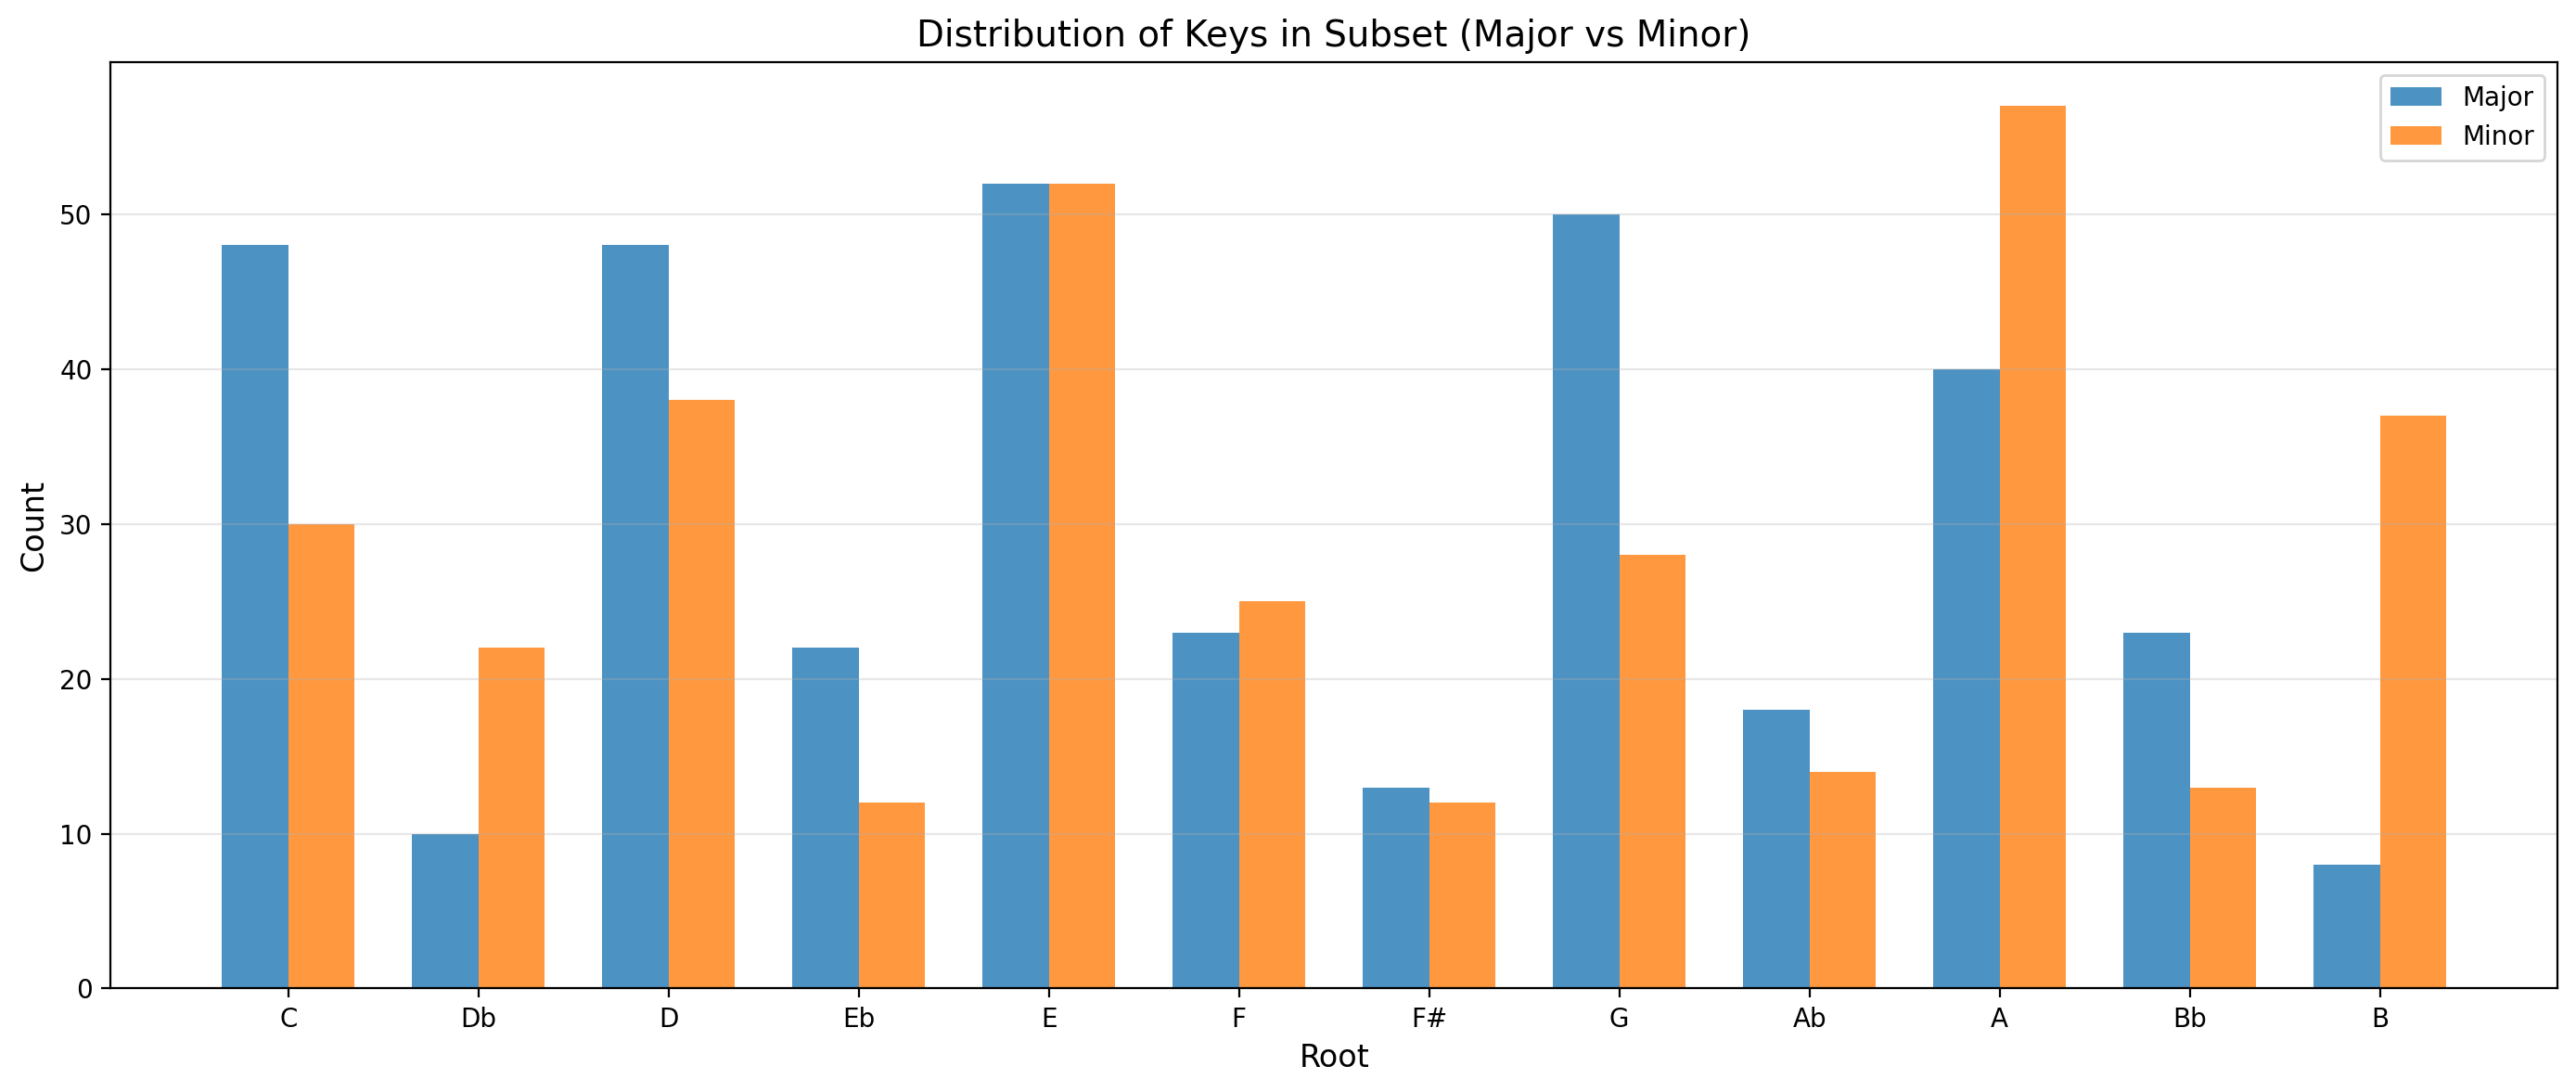

In [7]:
# Show distribution of keys by root with major vs. minor
actual_keys = np.array(list(actual_keys_dict.values()))

# Count major and minor for each root
key_counts = {root: {'major': 0, 'minor': 0} for root in u.ROOTS}

for key in actual_keys:
    parts = key.split()
    root = parts[0]
    mode = parts[1].lower()
    if root in key_counts:
        key_counts[root][mode] += 1

# Create bar chart
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(u.ROOTS))
width = 0.35

major_counts = [key_counts[root]['major'] for root in u.ROOTS]
minor_counts = [key_counts[root]['minor'] for root in u.ROOTS]

bars1 = ax.bar(x - width/2, major_counts, width, label='Major', alpha=0.8)
bars2 = ax.bar(x + width/2, minor_counts, width, label='Minor', alpha=0.8)

ax.set_xlabel('Root', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Keys in Subset (Major vs Minor)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(u.ROOTS)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Some keys are definitely more common than others! I guess no one likes music in F#...

# Run Predictions

Let's now use our methods to estimate the key for each of the tracks in the subset. 

- The Chroma + Krumhansl-Schuckler method is an engineered signal processing method that computes a chromagram, averages across the entire song, and determines which key matches best. See `u.krumhansl_schmuckler_predict` for details.
- The Madmom method uses the KeyNet model from this paper: https://arxiv.org/pdf/1808.05340. It is a convolutional neural network that predicts on log-magnitude spectrograms (not chromagrams). See `u.madmom_predict` for details.
- The Chroma transformer is our own model that predicts on full chromagrams. It uses transformers to learn from data how to aggregate over time. See `chroma_transformer/chroma_transformer.py` for details. For this demo, we created a special train/test split to train the model on all songs in FMAK except for the subset that we use here. This can be found in the `chroma_transformer/folds/fold_10` directory.

For each method, we provide code to run the predictions yourself if you want to. However, each of these methods is quite slow. For our project, we ran predictions on the full dataset using NYU's torch cluster with parallel processing. See `baseline_hpc/krumhansl_predict_keys.py` and `baseline_hpc/madmom_predict_keys.py` for details. To avoid running the slow prediction code, we have provided pre-run saves for you to quickly load the predictions.

### Chroma + Krumhansl-Schmuckler Method

In [ ]:
# Run this cell for Krumhansl-Schmuckler prediction on the subset of tracks
krumhansl_keys_dict = {}

for track_id in track_ids:
    print(f"Processing track {track_id}...")
    clear_output(wait=True)
    track = dataset.track(track_id)
    krumhansl_key_raw = u.krumhansl_schmuckler_predict(track)
    krumhansl_key = u.normalize_key(krumhansl_key_raw)
    krumhansl_keys_dict[track_id] = krumhansl_key

# And save the results
np.save('saves/krumhansl_keys_dict.npy', krumhansl_keys_dict, allow_pickle=True)

In [8]:
# OR, run this cell to load predictions from the saves
krumhansl_keys_dict = np.load('saves/krumhansl_keys_dict.npy', allow_pickle=True).item()

### Madmom Method

In [ ]:
# Run this cell to run madmom key estimation on the subset of tracks
madmom_keys_dict = {}

for track_id in track_ids:
    print(f"Processing track {track_id}...")
    clear_output(wait=True)
    track = dataset.track(track_id)
    madmom_key_raw = u.madmom_key_predict(track)
    madmom_key = u.normalize_key(madmom_key_raw)
    madmom_keys_dict[track_id] = madmom_key

# And save the results
np.save('saves/madmom_keys_dict.npy', madmom_keys_dict, allow_pickle=True)

In [9]:
# OR, run this cell to load predictions from the saves
madmom_keys_dict = np.load('saves/madmom_keys_dict.npy', allow_pickle=True).item()

### Chroma Transfomer

In [ ]:
# Run this cell to run chroma transformer key estimation on the subset of tracks
chroma_transformer_keys_dict = {}

for track_id in track_ids:
    print(f"Processing track {track_id}...")
    clear_output(wait=True)
    track = dataset.track(track_id)
    chroma_transformer_key_raw = u.chroma_transformer_predict(track)
    chroma_transformer_key = u.normalize_key(chroma_transformer_key_raw)
    chroma_transformer_keys_dict[track_id] = chroma_transformer_key

# And save the results
np.save('saves/chroma_transformer_keys_dict.npy', chroma_transformer_keys_dict, allow_pickle=True)

In [10]:
# OR, run this cell to load predictions from the saves
chroma_transformer_keys_dict = np.load('saves/chroma_transformer_keys_dict.npy', allow_pickle=True).item()

# Quantitative Evaluation

To evaluate our models, let's start with some confusion matrices.

### Confusion Matrices

In [11]:
# Compute confusion matrices for each model
krumhansl_keys = np.array([krumhansl_keys_dict[track_id] for track_id in track_ids])
madmom_keys = np.array([madmom_keys_dict[track_id] for track_id in track_ids])
chroma_transformer_keys = np.array([chroma_transformer_keys_dict[track_id] for track_id in track_ids])

# function to plot the confusion matrix
def plot_confusion_matrix(predicted_keys, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay.from_predictions(actual_keys, predicted_keys, ax=ax, cmap='Blues')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.xlabel('Predicted Key')
    plt.ylabel('Actual Key')
    plt.title(title)
    plt.tight_layout()
    plt.show()

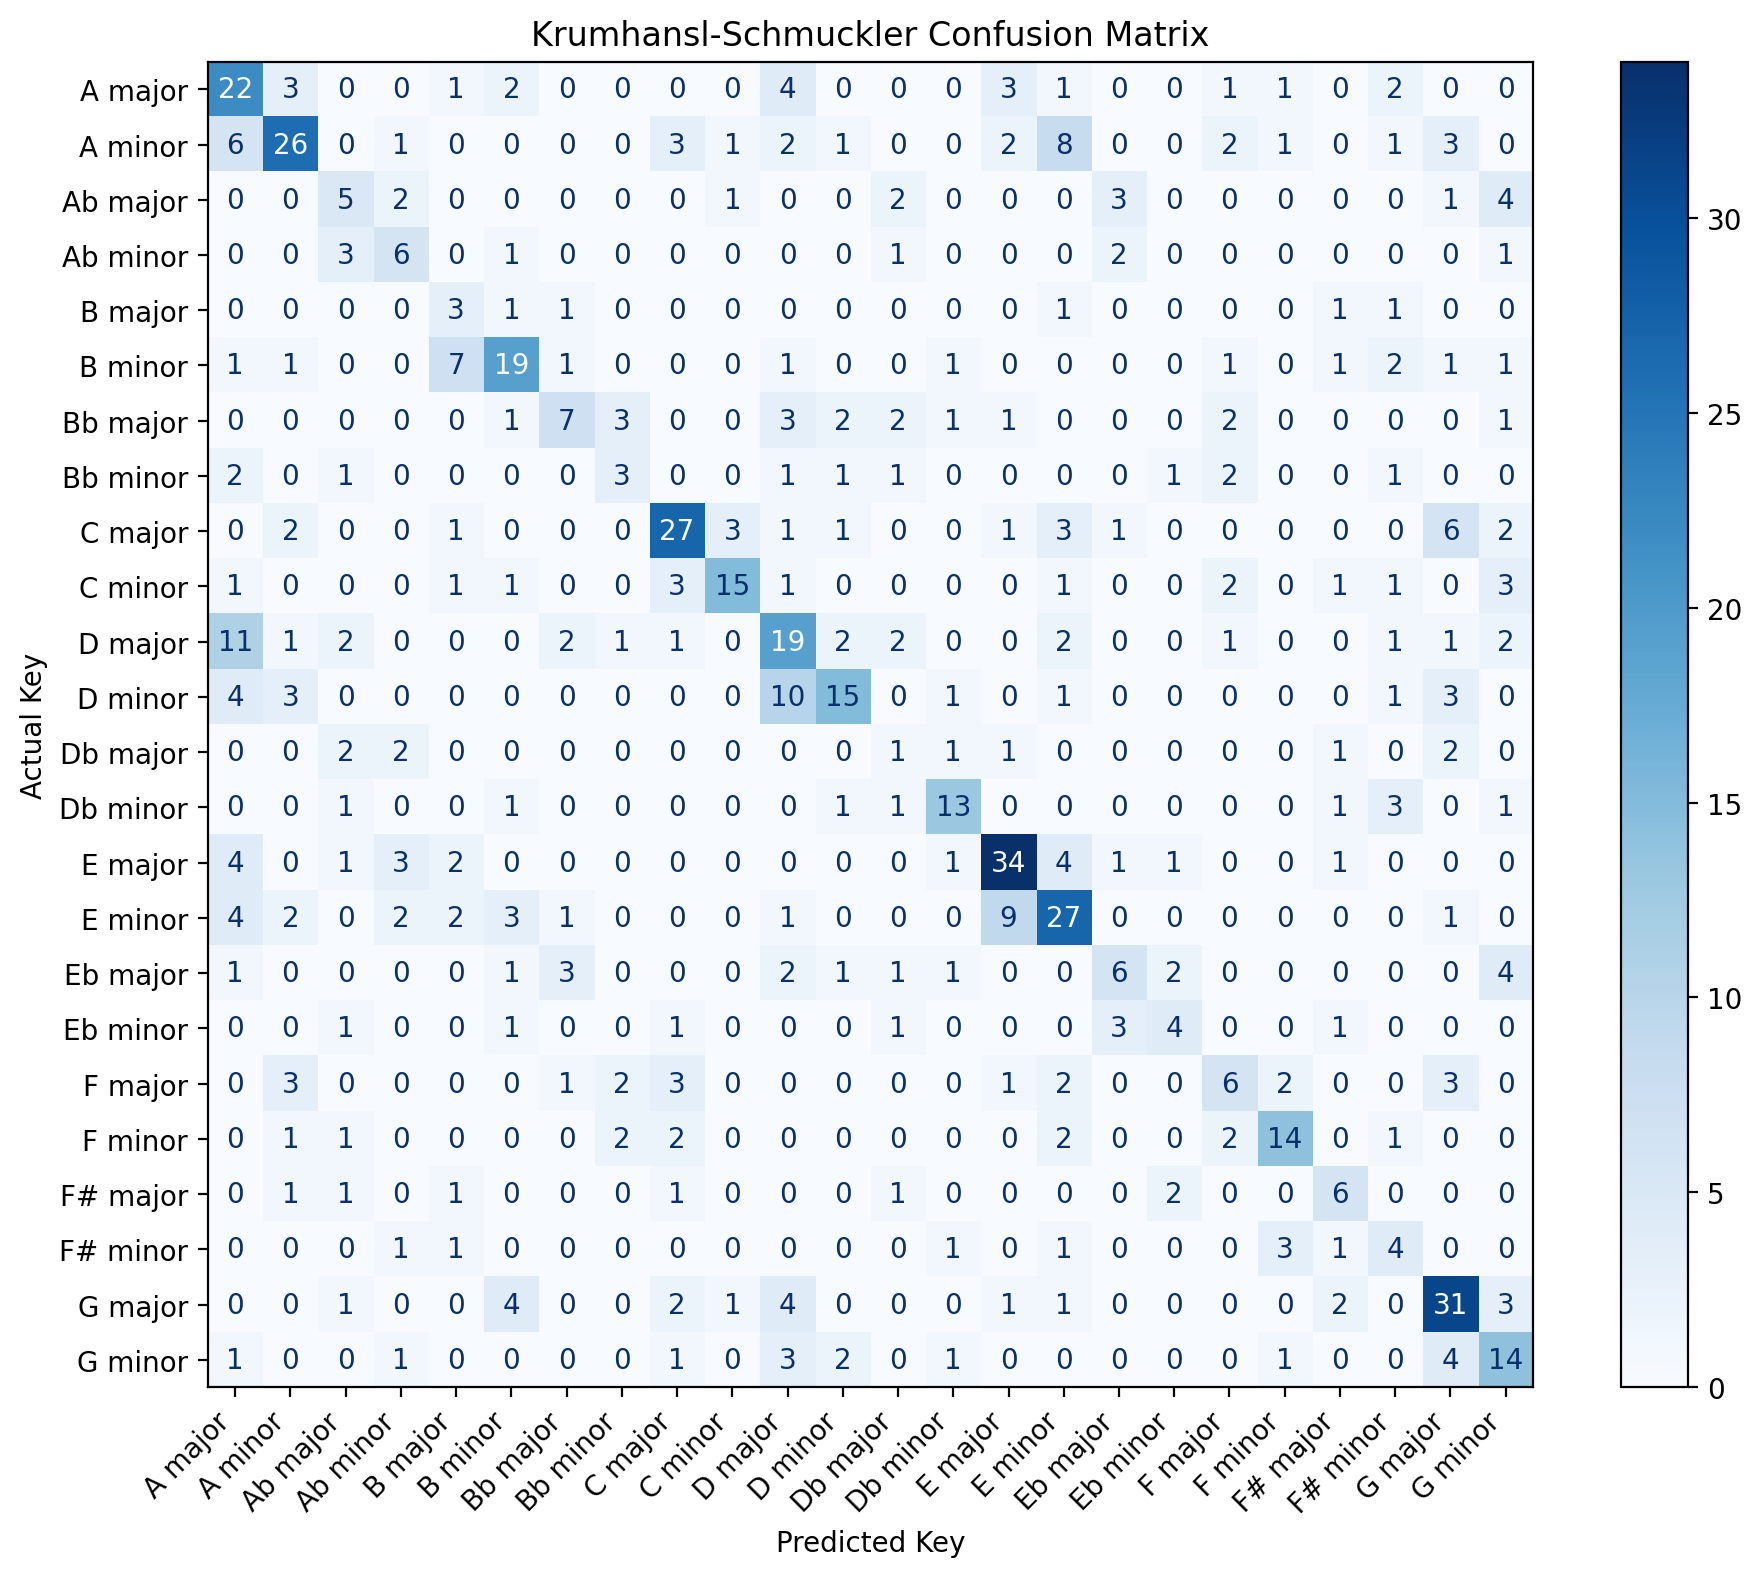

In [12]:
plot_confusion_matrix(krumhansl_keys, "Krumhansl-Schmuckler Confusion Matrix")

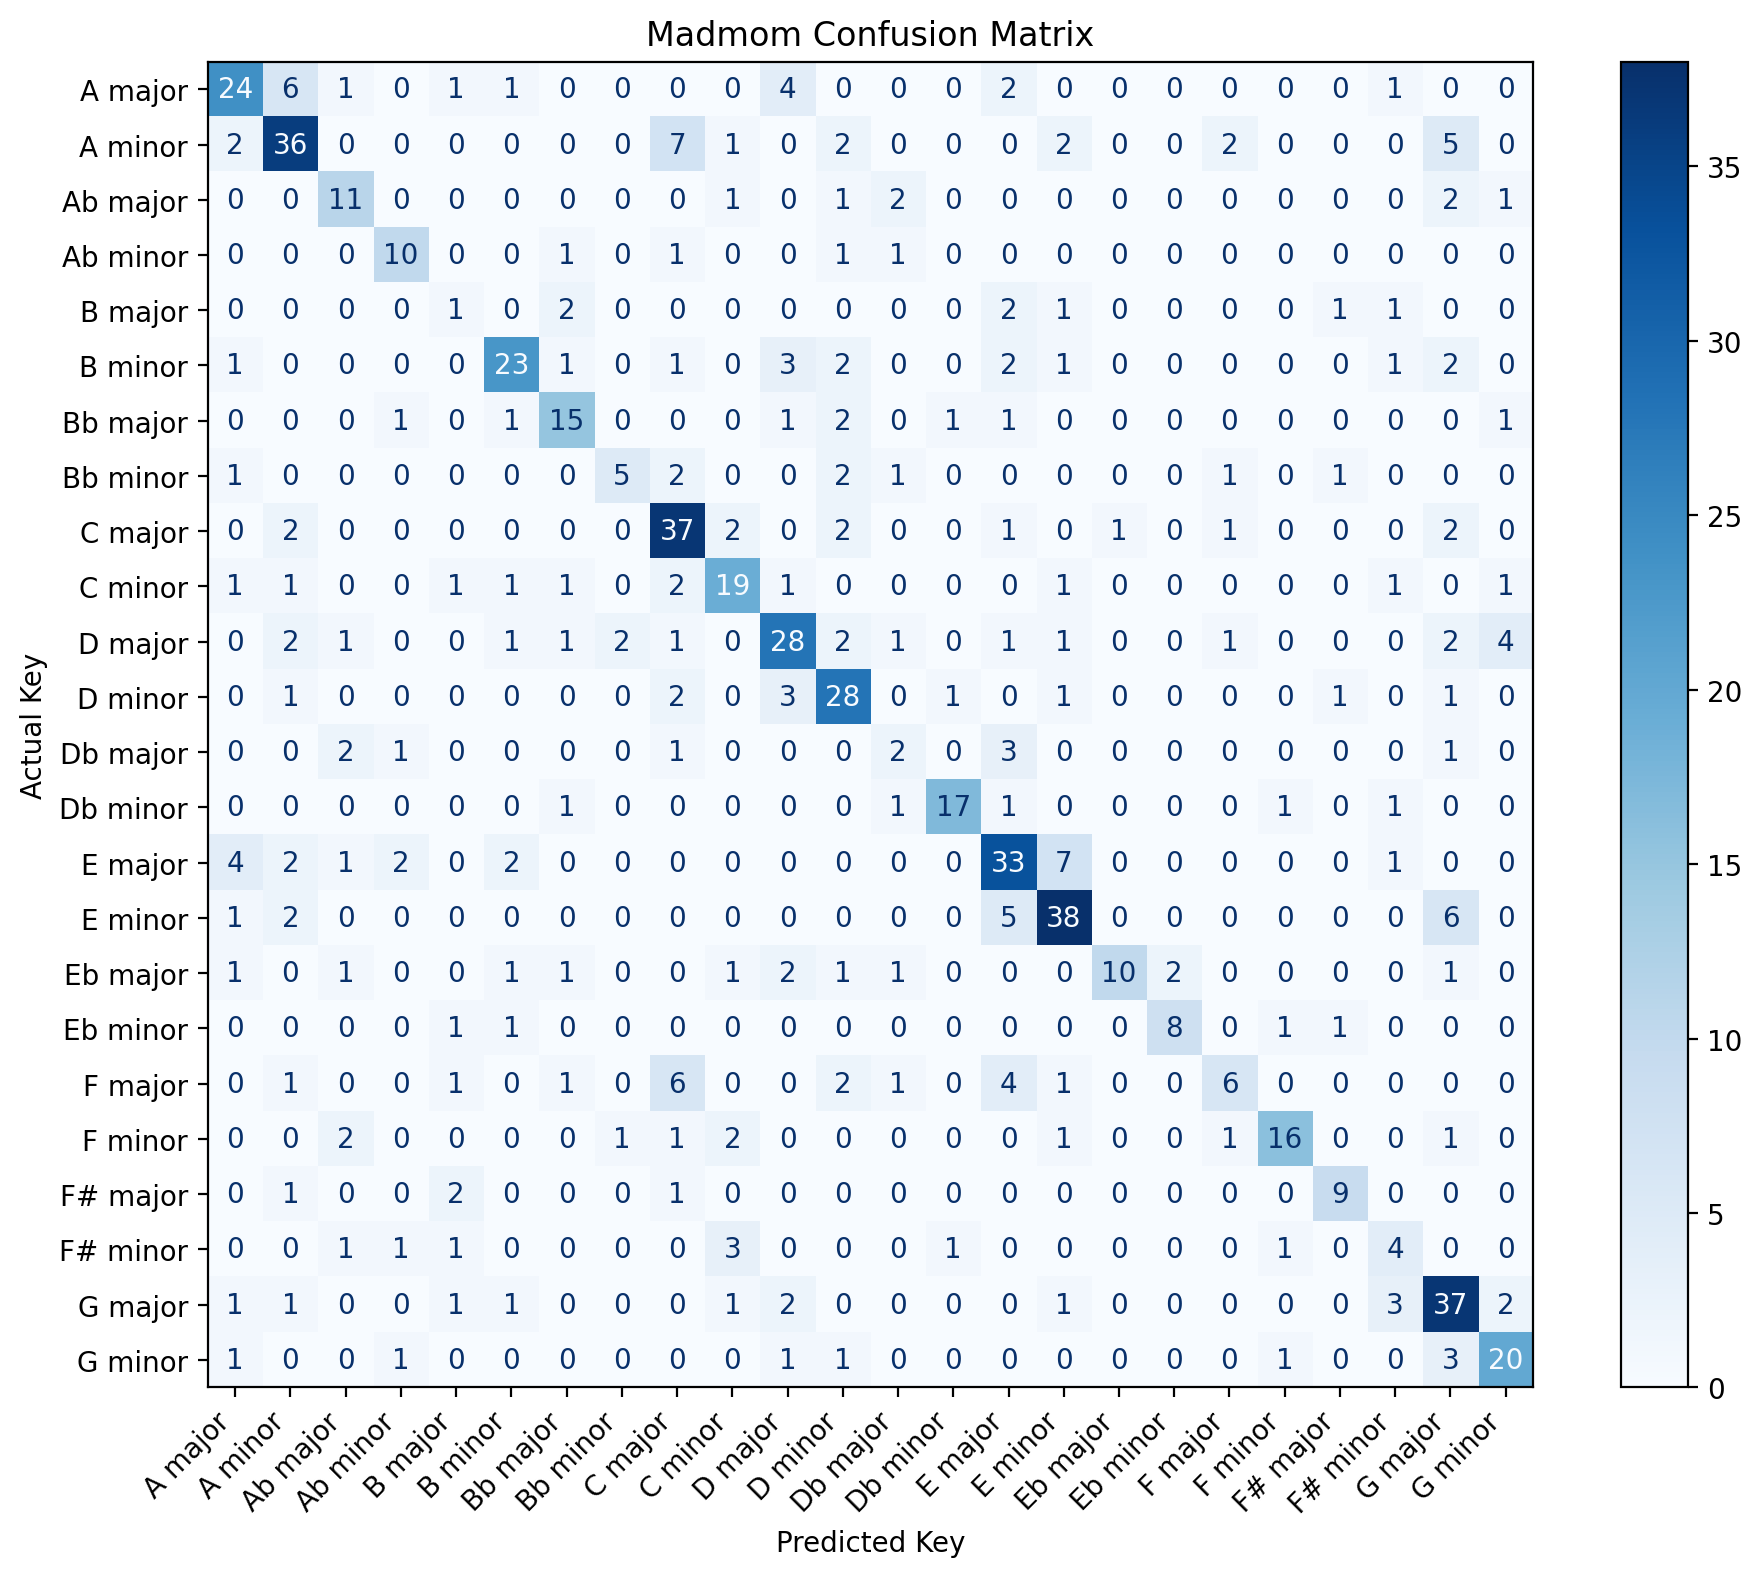

In [13]:
plot_confusion_matrix(madmom_keys, "Madmom Confusion Matrix")

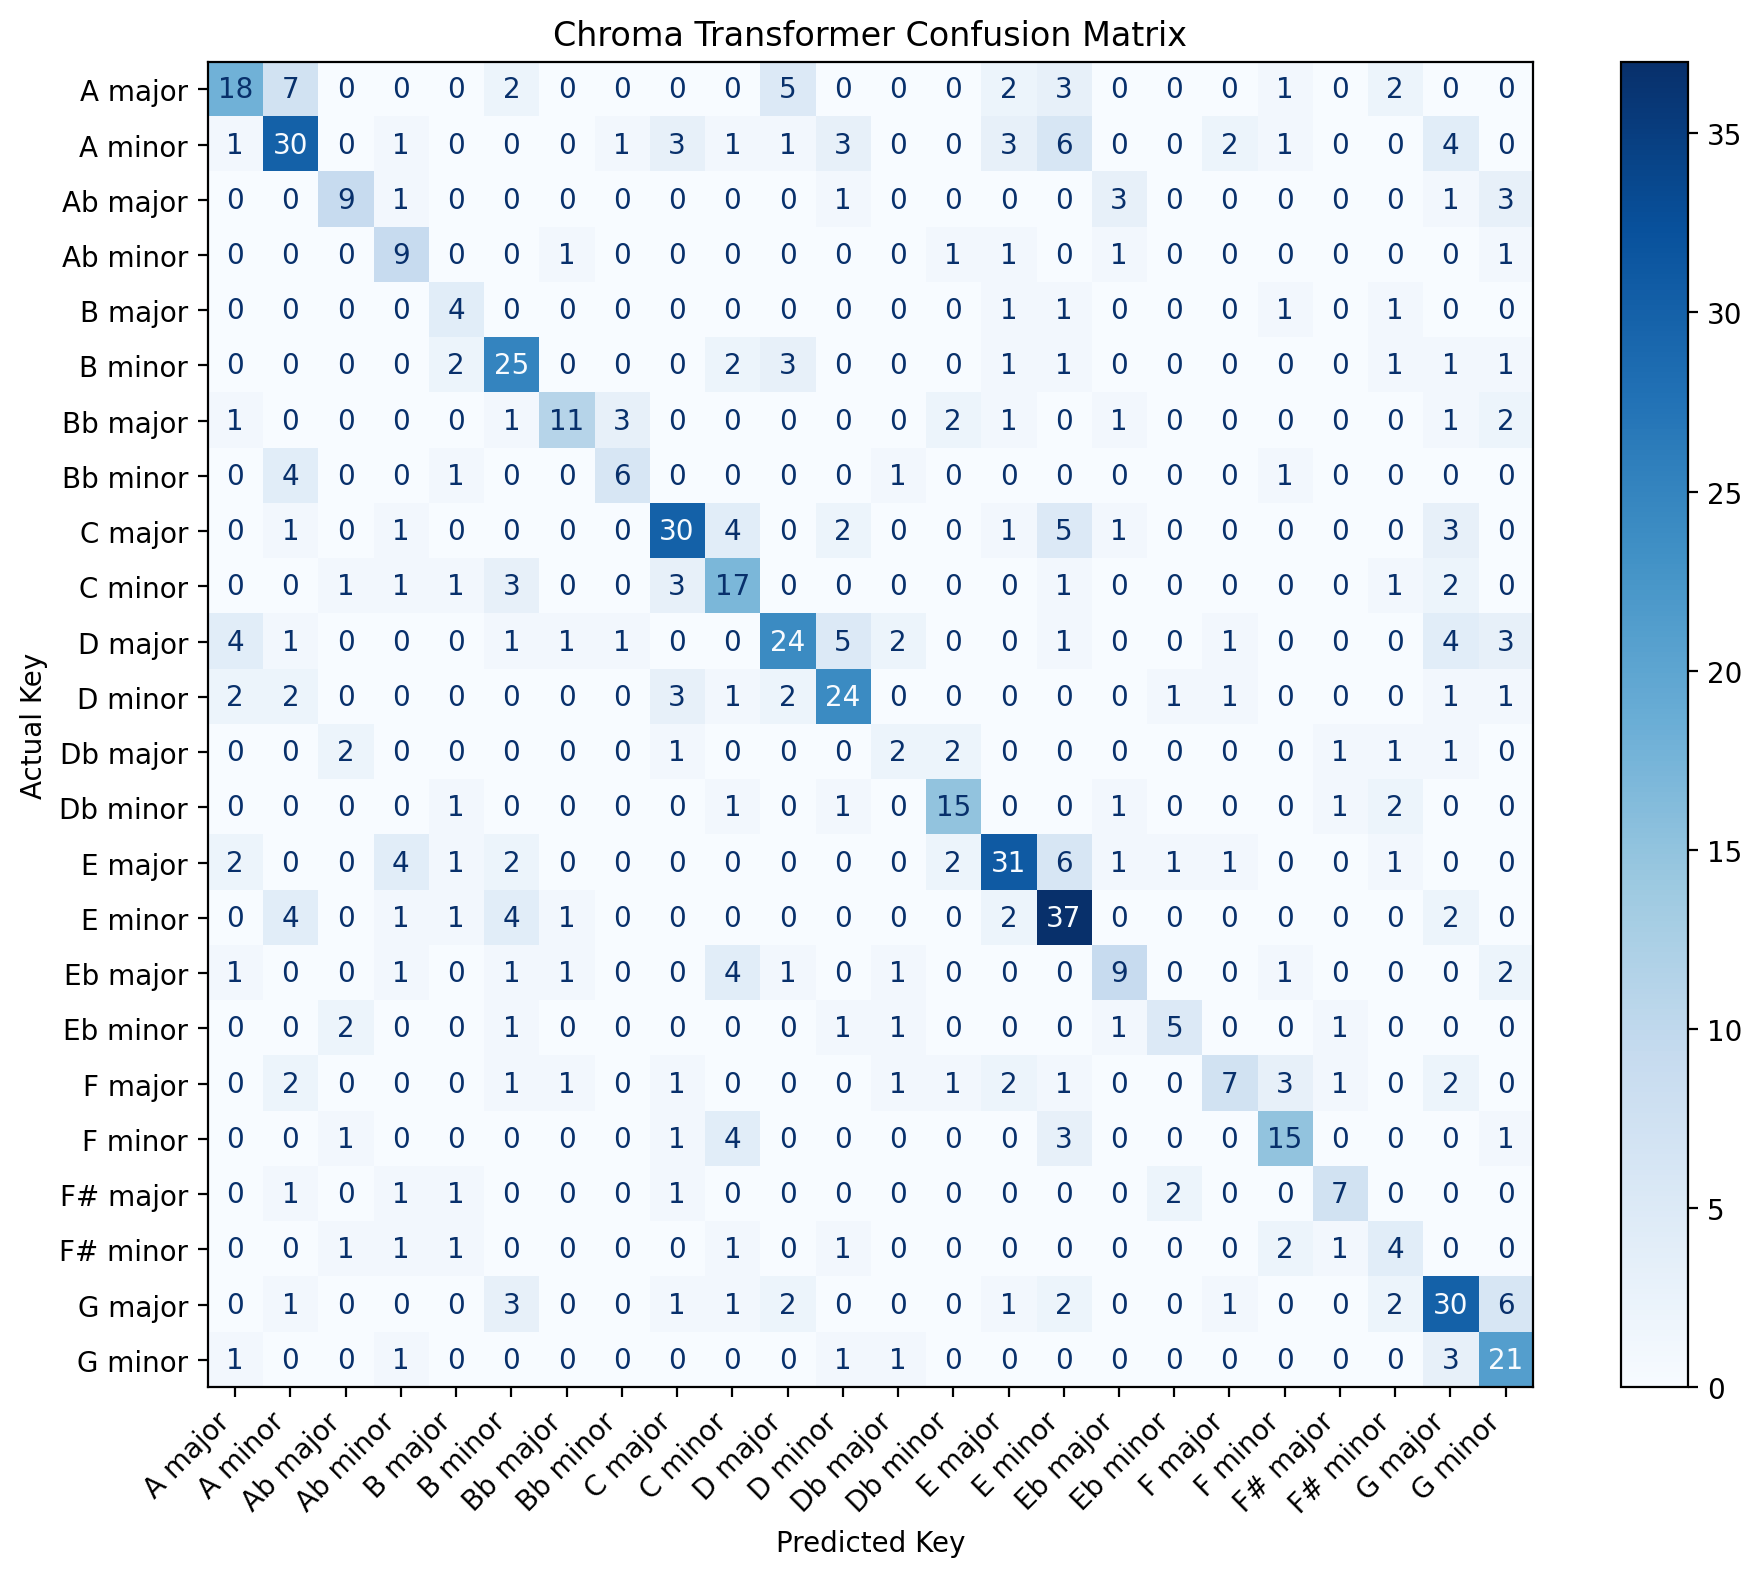

In [14]:
plot_confusion_matrix(chroma_transformer_keys, "Chroma Transformer Confusion Matrix")

We can see that all methods show pretty good activation along the diagonal (indicating correct predictions), but each method definitely makes some errors, too. With a confusion matrix this large, though, it's challenging to discern any patterns.

### Metrics

To better understand what's going on, let's look at some metrics. There are some useful utilities functions for this. A couple notes here:

1) Since this is a multi-class prediction problem, we have to choose how to aggregate  precision, recall, and F1 across classes. We chose "macro," which performs an unweighted average across classes (i.e. treating each class equally). This is because we don't have any reason to believe that the key distribution in our dataset is representative of the key distribution in music at large, and we'd like our key estimators to perform equally well across keys.

2) The "Average MIREX Score" is a music-informed metric which penalizes predictions that are less musically plausible (i.e. F# major is a much worse guess than G major when the actual key is C major). It evaluates the harmonic and modal proximity of a prediction to the ground-truth key. A score for each prediction is computed as follows:

| Relation to Correct Key | Points |
|---|---|
| Same | 1.0 |
| Perfect fifth | 0.5 |
| Relative major/minor | 0.3 |
| Parallel major/minor | 0.2 |
| Other | 0.0 |

We then average these computed scores across all predictions in the subset. Note that this metric has a weird quirk where the fifth category only includes keys that are a fifth above (and not a fifth below). This is supposed to be fixed in the future.

In [15]:
u.print_metrics(u.get_metrics(krumhansl_keys, actual_keys), "Chroma + Krumhansl-Schmuckler")
print()
u.print_metrics(u.get_metrics(madmom_keys, actual_keys), "Madmom")
print()
u.print_metrics(u.get_metrics(chroma_transformer_keys, actual_keys), "Chroma Transformer")

=== Chroma + Krumhansl-Schmuckler ===
Accuracy: 0.4705
Precision (Macro): 0.4322
Recall (Macro): 0.4248
F1 Score (Macro): 0.4214
Average MIREX Score: 0.5447

=== Madmom ===
Accuracy: 0.6288
Precision (Macro): 0.6103
Recall (Macro): 0.5794
F1 Score (Macro): 0.5866
Average MIREX Score: 0.6706

=== Chroma Transformer ===
Accuracy: 0.5612
Precision (Macro): 0.5354
Recall (Macro): 0.5291
F1 Score (Macro): 0.5243
Average MIREX Score: 0.6155


This gives a a better a better picture of what's going on! Each method performs much better than chance (which would be an accuracy of about 0.042 for this 24 class prediction problem). But these methods are all far from perfect. Across all metrics shown here, the Madmom estimator performs the best while the Chroma + Krumhansl-Schmuckler method performs worst. Our method falls somewhere in the middle.

Another thing that we can look at is specific kinds of errors. The following functions show what proportion of errors are relative key or parallel key errors:

In [12]:
print("=== Chroma + Krumhansl-Schmuckler ===")
print("Relative Key Error Proportion:", u.get_relative_key_error_proportion(krumhansl_keys, actual_keys))
print("Parallel Key Error Proportion:", u.get_parallel_key_error_proportion(krumhansl_keys, actual_keys))
print()

print("=== Madmom ===")
print("Relative Key Error Proportion:", u.get_relative_key_error_proportion(madmom_keys, actual_keys))
print("Parallel Key Error Proportion:", u.get_parallel_key_error_proportion(madmom_keys, actual_keys))
print()

print("=== Chroma Transformer ===")
print("Relative Key Error Proportion:", u.get_relative_key_error_proportion(chroma_transformer_keys, actual_keys))
print("Parallel Key Error Proportion:", u.get_parallel_key_error_proportion(chroma_transformer_keys, actual_keys))


=== Chroma + Krumhansl-Schmuckler ===
Relative Key Error Proportion: 0.04619565217391304
Parallel Key Error Proportion: 0.20380434782608695

=== Madmom ===
Relative Key Error Proportion: 0.11627906976744186
Parallel Key Error Proportion: 0.14728682170542637

=== Chroma Transformer ===
Relative Key Error Proportion: 0.09180327868852459
Parallel Key Error Proportion: 0.17049180327868851


Interestingly, the Chroma + Krumhansl-Schmuckler method makes the fewest relative key errors, but the most parallel keys errors. The other two methods are a bit more balanced.

### Key Distance

Another way to evaluate musical errors is by seeing how far the predicted keys are from the actual keys in terms of key distance by comparing the number of notes shared by the predicted and ground-truth keys. Ideally, our models should make errors that seem musically reasonable (like guessing G major when the key is C major). 

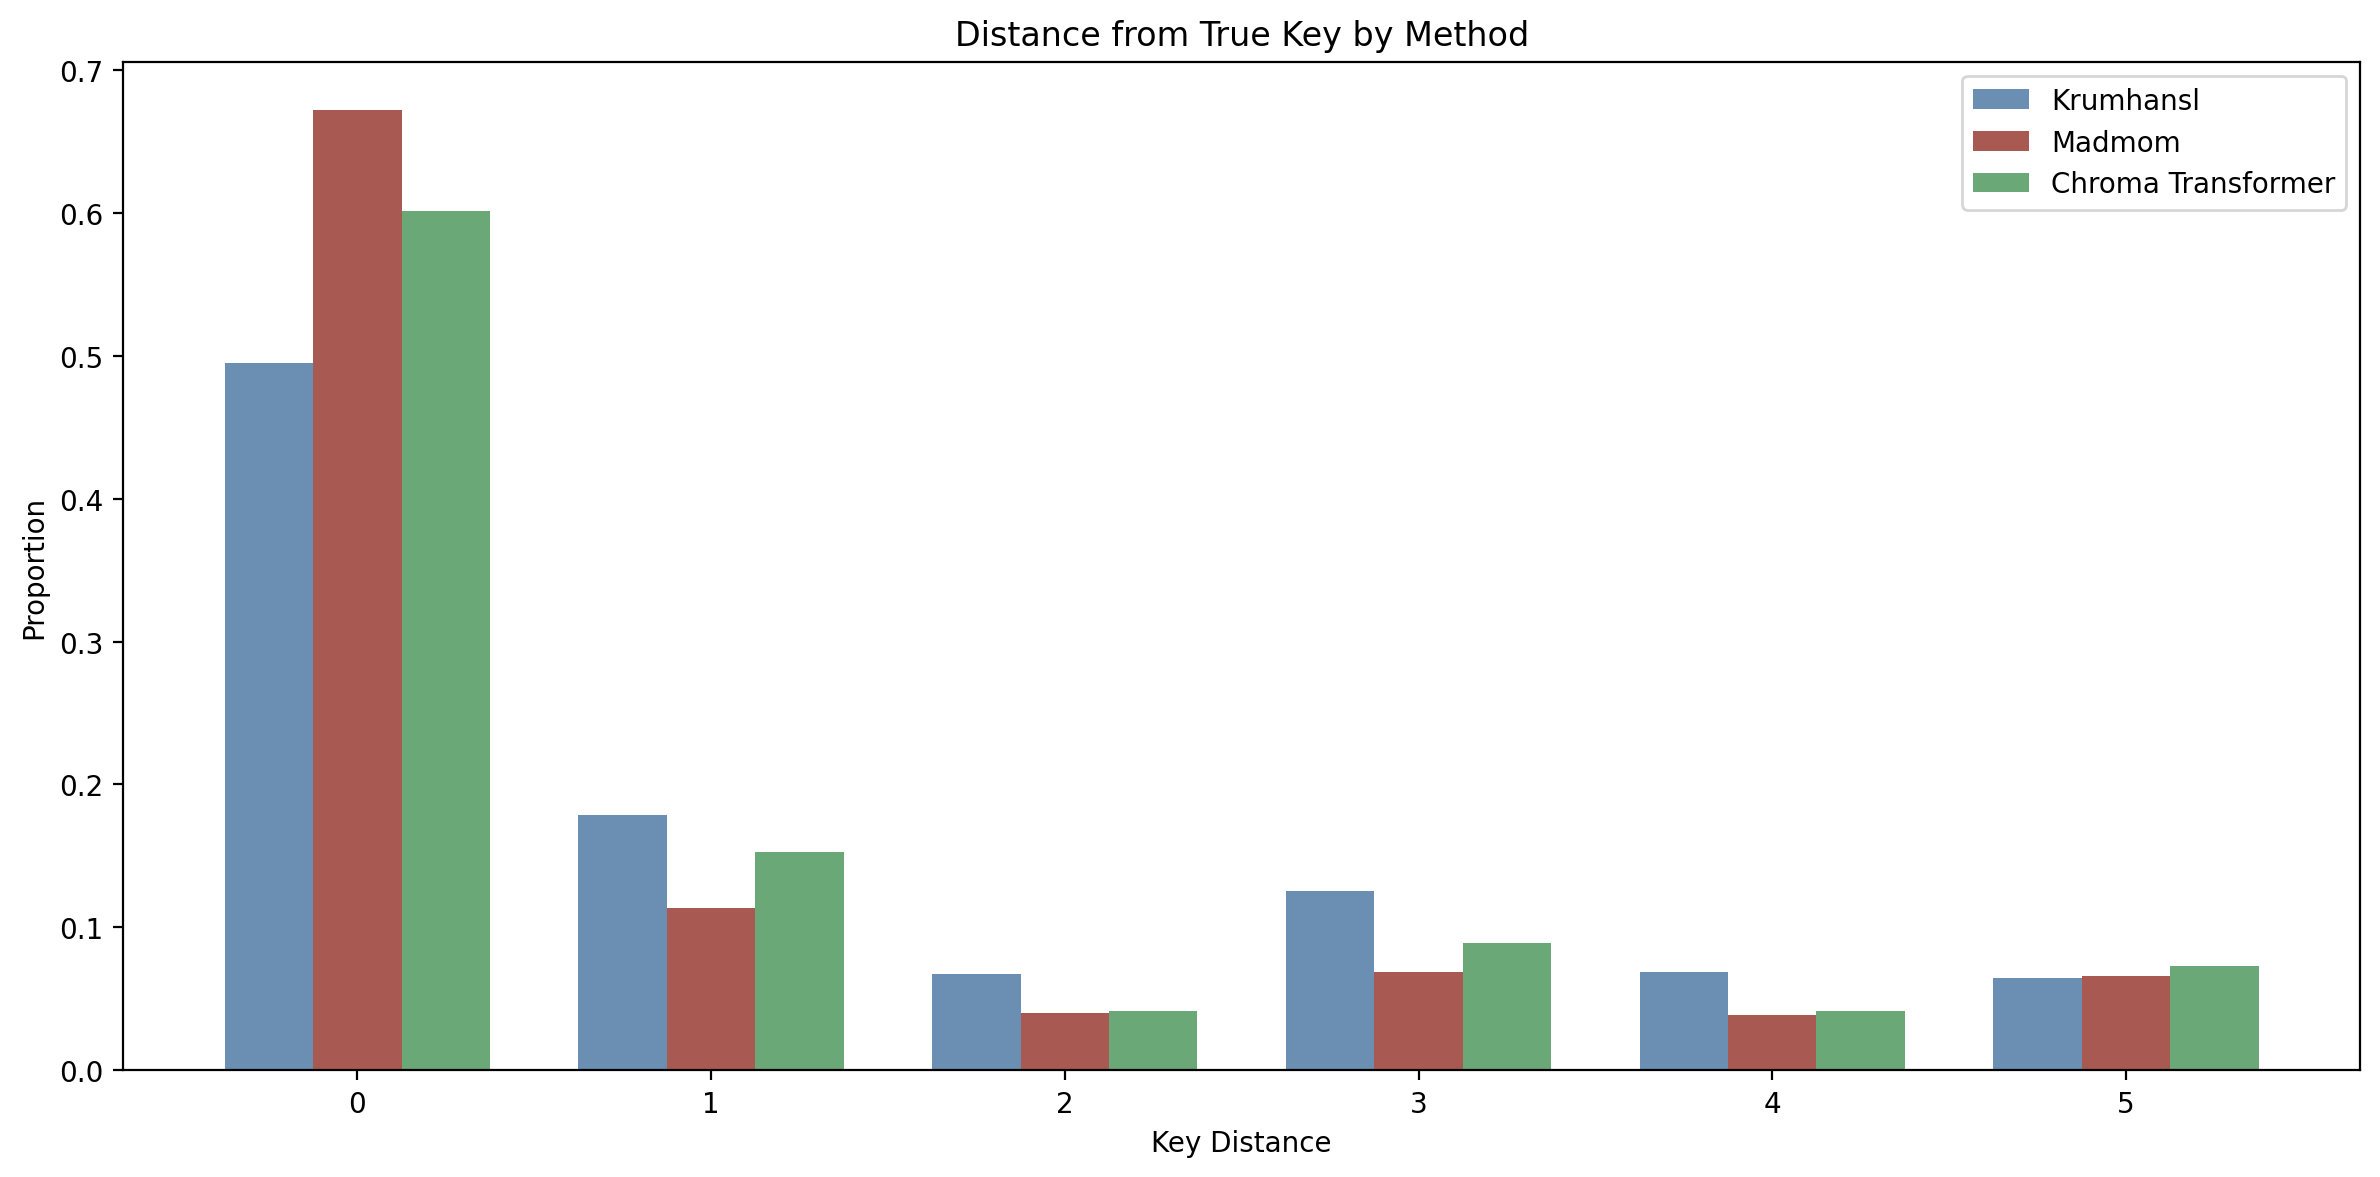

In [19]:
# Calculate key distance distributions
krumhansl_key_distances = [u.get_key_distance(pred, true) for pred, true in zip(krumhansl_keys, actual_keys)]
madmom_key_distances = [u.get_key_distance(pred, true) for pred, true in zip(madmom_keys, actual_keys)]
chroma_transformer_key_distances = [u.get_key_distance(pred, true) for pred, true in zip(chroma_transformer_keys, actual_keys)]
krumhansl_dist_counter = Counter(krumhansl_key_distances)
madmom_dist_counter = Counter(madmom_key_distances)
chroma_transformer_dist_counter = Counter(chroma_transformer_key_distances)

# Get all unique distances sorted
all_distances = sorted(set(krumhansl_key_distances) | set(madmom_key_distances) | set(chroma_transformer_key_distances))

# Convert to proportions
total = len(krumhansl_key_distances)
krumhansl_proportions = [krumhansl_dist_counter.get(d, 0) / total for d in all_distances]
madmom_proportions = [madmom_dist_counter.get(d, 0) / total for d in all_distances]
chroma_transformer_proportions = [chroma_transformer_dist_counter.get(d, 0) / total for d in all_distances]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(all_distances))
width = 0.25

ax.bar(x - width, krumhansl_proportions, width, label='Krumhansl', color='#6b8fb3')
ax.bar(x, madmom_proportions, width, label='Madmom', color='#a85a52')
ax.bar(x + width, chroma_transformer_proportions, width, label='Chroma Transformer', color='#6ba878')

ax.set_xlabel('Key Distance')
ax.set_ylabel('Proportion')
ax.set_title('Distance from True Key by Method')
ax.set_xticks(x)
ax.set_xticklabels(all_distances)
ax.legend()

plt.tight_layout()
plt.show()

It does seem like each method makes errors where the predicted key is 1 note different than actual key. However, we don't see the clear downward trend we might expect (e.g. where predicted keys that 3 notes off are less likely than predicted keys which are 2 notes off). This is a bit surprising, but points to the non-robustness of the methods, and potentially issues with the data or task framing.

# Qualitative Evaluation

Let's listen to some of the tracks to get a clearer understanding of the errors. We'll inspect tracks that all methods failed on to see some of the hardest samples.

In [11]:
is_failure = (
    (krumhansl_keys != actual_keys) & 
    (madmom_keys != actual_keys) & 
    (chroma_transformer_keys != actual_keys)
)

failure_track_ids = [track_id for track_id, fail in zip(track_ids, is_failure) if fail]
print(f"There are {len(failure_track_ids)} tracks where all models failed to predict the correct key.")

There are 170 tracks where all models failed to predict the correct key.


In [ ]:
# Print details and display audio for the first few failure cases
# By default this cell will be un-run, because saving the audio in the notebook is too large for git
for track_id in failure_track_ids[:5]:
    track = dataset.track(track_id)
    print(f"Track ID: {track_id}")
    print(f"Actual Key: {actual_keys_dict[track_id]}")
    print(f"Krumhansl Prediction: {krumhansl_keys_dict[track_id]}")
    print(f"Madmom Prediction: {madmom_keys_dict[track_id]}")
    print(f"Chroma Transformer Prediction: {chroma_transformer_keys_dict[track_id]}")
    
    y, sr = track.audio
    ipd.display(ipd.Audio(y, rate=sr))
    print()

Here are notes on each track

Track 153:
While this track has clear chords, the harmony is highly non-functional. There really isn't  a correct "key" here. The song starts on a Db major chord, so maybe that's where the annotation is coming from, but the song doesn't feel like it's in Db major.

Track 173:
The label just seems wrong here. B major (which two of the methods guess) seems like the best fit for this song. This is an annotation issue, not a model issue.

Track 411:
This is a beautiful song. Again, the label is highly suspect. Certainly, there is a tonal center of G here, which the models and label all agree on. However, the song seems to be about tension/release cycles, where the major tonality feels most consonant. G major is probably a better label.

Track 532:
This song centers around the Eb minor (or perhaps Gb major) pentatonic scale. It's tough to say what the key is here, but the annotated Eb major is definitely wrong: G-natural and D-natural both feel very out of place.

Track ID: 535
This song modulates from F# major to B major, so it's quite challenging to give a single label to this song.

# Takeaways

Hopefully this notebook gave you a sense of the following:
- Key estimators can work, but are far from perfect. The best method we saw was madmom, which achieved 63% accuracy on this dataset, while the worst method, Chroma + Krumhansl-Schmuckler achieved an accuracy of 47%. This is far from random guessing, but also leaves much room for improvement.
- The errors that estimators make are not always musically plausible. Sometimes the estimators are just plain off.

HOWEVER,
- Key annotation is very challenging. There are situations where it's genuinely challenging to give a key label--heavy chromaticism, non-functional harmony, and key changes all complicate this task.
- This dataset in particular has some clear flaws. The annotations are far from perfect.